Rozmiar ramki (domyślne typy): 1550.68 MB
sid                    int64
sid_profile            int64
post_id                  str
profile_id             int64
date                     str
post_type              int64
description              str
likes                  int64
comments               int64
username                 str
bio                      str
following              int64
followers              int64
num_posts              int64
is_business_account     bool
lang                     str
category                 str
dtype: object
Rozmiar ramki (zoptymalizowane): 1435.79 MB


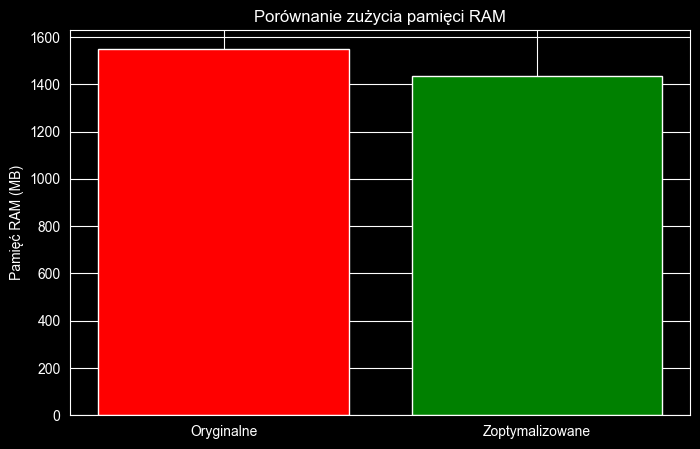

In [6]:
import pandas as pd
import numpy as np
import os
import time
import matplotlib.pyplot as plt
files = [f'data/{f}' for f in os.listdir('data/') if f.endswith('.parquet')]
df_list = [pd.read_parquet(f) for f in files]
df_orig = pd.concat(df_list, ignore_index=True)
mem_orig = df_orig.memory_usage(deep=True).sum() / (1024**2)
print(f"Rozmiar ramki (domyślne typy): {mem_orig:.2f} MB")
print(df_orig.dtypes)
#Zadanie 2
def optimize_dtypes(df):
    df_opt = df.copy()
    for col in df_opt.columns:
        col_type = df_opt[col].dtype
        if col_type == 'object':
            if df_opt[col].nunique() / len(df_opt) < 0.5:
                df_opt[col] = df_opt[col].astype('category')
        elif 'int' in str(col_type):
            df_opt[col] = pd.to_numeric(df_opt[col], downcast='integer')
        elif 'float' in str(col_type):
            df_opt[col] = pd.to_numeric(df_opt[col], downcast='float')
    return df_opt
df_opt = optimize_dtypes(df_orig)
mem_opt = df_opt.memory_usage(deep=True).sum() / (1024**2)
print(f"Rozmiar ramki (zoptymalizowane): {mem_opt:.2f} MB")
plt.figure(figsize=(8, 5))
plt.bar(['Oryginalne', 'Zoptymalizowane'], [mem_orig, mem_opt], color=['red', 'green'])
plt.ylabel('Pamięć RAM (MB)')
plt.title('Porównanie zużycia pamięci RAM')
plt.show()

In [8]:
#Zadanie 3
def benchmark_operations(df, label):
    print(f"Test danych: {label}")
    start = time.time()
    col_likes = 'likes' if 'likes' in df.columns else 'likes_count'
    if col_likes in df.columns:
        res1 = df[df[col_likes] > 10]
    col_group = 'is_video' if 'is_video' in df.columns else None
    if not col_group:
        potential_cols = [c for c in df.columns if df[c].nunique() < 10]
        col_group = potential_cols[0] if potential_cols else df.columns[0]
    res2 = df.groupby(col_group)[col_likes].mean() if col_group in df.columns else None
    col_sort = 'timestamp' if 'timestamp' in df.columns else df.columns[0]
    res3 = df.sort_values(by=col_sort, ascending=False)
    end = time.time()
    print(f"Czas wykonania: {end - start:.4f}.\n")
benchmark_operations(df_orig, "Oryginalnych")
benchmark_operations(df_opt, "Zoptymalizowanych")

Test danych: Oryginalnych
Czas wykonania: 7.1595.

Test danych: Zoptymalizowanych
Czas wykonania: 6.9452.



In [6]:
#Zadanie 4
df_orig.to_csv('combined_data.csv', index=False)
size_parquet = sum(os.path.getsize(f'data/{f}') for f in os.listdir('data/') if f.endswith('.parquet')) / (1024**2)
size_csv = os.path.getsize('combined_data.csv') / (1024**2)
print(f"Suma Parquet: {size_parquet:.2f} MB")
print(f"Plik CSV: {size_csv:.2f} MB")

Suma Parquet: 539.06 MB
Plik CSV: 1330.57 MB


In [ ]:
#Zadanie 5
import multiprocessing as mp
filename = 'combined_data.csv'
s = time.time()
_ = pd.read_csv(filename)
print(f"Wczytywanie (standard): {time.time() - s:.4f}s")
s = time.time()
chunks = pd.read_csv(filename, chunksize=50000)
for chunk in chunks:
    pass
print(f"Wczytywanie (chunksize): {time.time() - s:.4f}s")
def split_csv(fname, n_parts):
    df = pd.read_csv(fname)
    rows_per_part = len(df) // n_parts
    for i in range(n_parts):
        df.iloc[i*rows_per_part : (i+1)*rows_per_part].to_csv(f'part_{i}.csv', index=False)
n_cores = mp.cpu_count()
parts_list = [n_cores - 2, (n_cores - 2) * 2]
def read_part(fname):
    return pd.read_csv(fname)
for p in parts_list:
    split_csv(filename, p)
    files_to_read = [f'part_{i}.csv' for i in range(p)]
    s = time.time()
    with mp.Pool(processes=p) as pool:
        results = pool.map(read_part, files_to_read)
    df_multi = pd.concat(results)
    print(f"Wczytywanie (Multiprocessing, p={p}): {time.time() - s:.4f}s")

Wczytywanie (standard): 26.0423s
Wczytywanie (chunksize): 24.2068s
